In [1]:
import os
import pathlib
import sys

# include .. 
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
from astropy.io import fits

import matplotlib
from matplotlib import pyplot as plt
from matplotlib import cm
# from .qso_loader import QSOLoader, file_loader
# from .qso_loader_dr16q import QSOLoaderDR16Q
# from .set_parameters import *
# from .dla_data import dla_data
from CDDF_analysis.dla_data import dla_data



cmap = cm.get_cmap("viridis")

# change fontsize
matplotlib.rcParams.update(
    {"font.size": 12, "axes.labelsize": 16, "axes.titlesize": 14}
)

# matplotlib.use('PDF')
save_figure = lambda filename: plt.savefig(
    "{}.pdf".format(filename), format="pdf", dpi=300
)



/var/folders/sn/b7hd1bmd569cjwgmtww4mv440000gn/T/ipykernel_79970/2687069322.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
from astropy.io import fits

data = fits.open("~/Downloads/DR16Q_v4.fits")[1].data

In [28]:
ind_sn = data["SN_MEDIAN_ALL"] > 2.0
ind_sn &= ~(data["AI_CIV"] > 0)
ind_sn &= ~(data["BAL_PROB"] > 0)

ind = (data["CONF_DLA"][ind_sn] > 0.9)
ind &= (data["NHI_DLA"][ind_sn] >= 20.3)
(ind).sum()

16267

In [2]:


def plot_line_density(
    z_cent: np.ndarray,
    dNdX: np.ndarray,
    dndx68: np.ndarray,
    dndx95: np.ndarray,
    zmin: float = 2.0,
    zmax: float = 5.5,
    label: str = "GP",
    color="blue",
    bins_per_z: int = 6,
):
    """Plot the line density as a function of redshift"""
    # Get the redshifts
    nbins = np.max([int((zmax - zmin) * bins_per_z), 1])
    z_bins = np.linspace(zmin, zmax, nbins + 1)

    try:
        # hope this line works
        xerrs = (z_cent - z_bins[:-1], z_bins[1:] - z_cent)
    except ValueError as e:
        xerrs = (z_cent - z_bins[:-2], z_bins[1:-1] - z_cent)

    # 2 sigma contours.
    plt.fill_between(z_cent, dndx95[:, 0], dndx95[:, 1], color="grey", alpha=0.5)
    yerr = (dNdX - dndx68[:, 0], dndx68[:, 1] - dNdX)
    plt.errorbar(z_cent, dNdX, yerr=yerr, xerr=xerrs, fmt="o", color=color, label=label)
    plt.xlabel(r"z")
    plt.ylabel(r"dN/dX")
    plt.xlim(zmin, zmax)

def plot_cddf(
    l_N: np.ndarray,
    cddf: np.ndarray,
    cddf68: np.ndarray,
    cddf95: np.ndarray,
    lnhi_nbins: int = 30,
    lnhi_min: float = 20.0,
    lnhi_max: float = 23.0,
    color="blue",
    label="GP",
):
    """
    Plot cddf from variables, using same methods as calc_cddf.plot_cddf
    """
    # Get the NHI bins
    l_nhi = np.linspace(lnhi_min, lnhi_max, num=lnhi_nbins + 1)

    xerrs = (10 ** l_N - 10 ** l_nhi[:-1], 10 ** l_nhi[1:] - 10 ** l_N)

    # two sigma
    plt.fill_between(10 ** l_N, cddf95[:, 0], cddf95[:, 1], color="grey", alpha=0.5)

    # if has values
    yerr = (cddf - cddf68[:, 0], cddf68[:, 1] - cddf)
    ii = np.where(cddf68[:, 0] > 0.0)
    if np.size(ii) > 0:
        plt.errorbar(
            10 ** l_N[ii],
            cddf[ii],
            yerr=(yerr[0][ii], yerr[1][ii]),
            xerr=(xerrs[0][ii], xerrs[1][ii]),
            fmt="o",
            label=label,
            color=color,
        )

    # upper limits
    i2 = np.where(cddf68[:, 0] == 0)
    if np.size(i2) > 0:
        plt.errorbar(
            10 ** l_N[i2],
            cddf[i2] + yerr[1][i2],
            yerr=yerr[1][i2] / 2.0,
            xerr=(xerrs[0][i2], xerrs[1][i2]),
            fmt="o",
            label=None,
            uplims=True,
            color=color,
            lw=2,
        )
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel(r"$N_\mathrm{HI}$ (cm$^{-2}$)")
    plt.ylabel(r"$f(N_\mathrm{HI})$")



def plot_omega_dla(
    z_cent: np.ndarray,
    omega_dla: np.ndarray,
    omega_dla_68: np.ndarray,
    omega_dla_95: np.ndarray,
    zmin: float = 2.0,
    zmax: float = 5.5,
    label: str = "GP",
    color: str = "blue",
    twosigma: bool = True,
    bins_per_z: int = 6,
):
    """Plot omega_DLA as a function of redshift, with full Bayesian errors"""
    nbins = np.max([int((zmax - zmin) * bins_per_z), 1])
    z_bins = np.linspace(zmin, zmax, nbins + 1)

    try:
        # hope this line works
        xerrs = (z_cent - z_bins[:-1], z_bins[1:] - z_cent)
    except ValueError as e:
        xerrs = (z_cent - z_bins[:-2], z_bins[1:-1] - z_cent)

    # import pdb
    # pdb.set_trace()

    if twosigma:
        plt.fill_between(
            z_cent,
            1000 * omega_dla_95[:, 0],
            1000 * omega_dla_95[:, 1],
            color="grey",
            alpha=0.5,
        )
    yerr = (
        omega_dla - 1000 * omega_dla_68[:, 0],
        1000 * omega_dla_68[:, 1] - omega_dla,
    )
    plt.errorbar(
        z_cent, omega_dla, yerr=yerr, xerr=xerrs, fmt="s", label=label, color=color
    )
    plt.xlabel(r"z")
    plt.ylabel(r"$10^3 \times \Omega_\mathrm{DLA}$")
    plt.xlim(zmin, zmax)


CDDF 

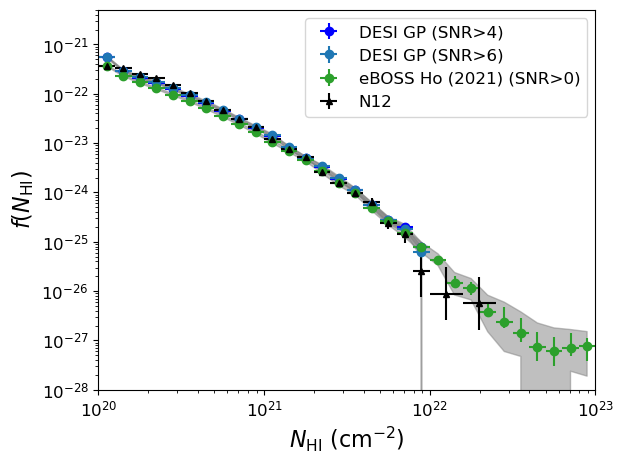

In [6]:
subdir = "../dla_cddf/dla_cddf_20250302/desi_snr4.0_zqsos_2.5-6.0_dla_5.5_occam_1.0_dla_model_3_subdla_lowzcut_zminlyb_highnhi_21.5_minobswave_3700.0_bins_3/"
high_snrsubdir = "../dla_cddf/dla_cddf_20250302/desi_snr6.0_zqsos_2.5-6.0_dla_5.5_occam_1.0_dla_model_3_subdla_lowzcut_zminlyb_highnhi_21.5_minobswave_3700.0_bins_3/"
# outfile = "../dla_cddf/"
outfile = "/Users/jibanmac/Documents/Latex/gp_dla_desi_y3/figures"

# Load Cddf
cddf_all = np.loadtxt(os.path.join(subdir, "cddf_all.txt"))
(_, N) = cddf_all.shape

cddf68 = np.full((N, 2), fill_value=np.nan)
cddf95 = np.full((N, 2), fill_value=np.nan)
(l_N, cddf, cddf68[:, 0], cddf68[:, 1], cddf95[:, 0], cddf95[:, 1]) = cddf_all

# Fiducial
plot_cddf(l_N, cddf, cddf68, cddf95, label="DESI GP (SNR>4)")

# High SNR
cddf_all = np.loadtxt(os.path.join(high_snrsubdir, "cddf_all.txt"))
(_, N) = cddf_all.shape

cddf68 = np.full((N, 2), fill_value=np.nan)
cddf95 = np.full((N, 2), fill_value=np.nan)
(l_N, cddf, cddf68[:, 0], cddf68[:, 1], cddf95[:, 0], cddf95[:, 1]) = cddf_all

# Fiducial
plot_cddf(l_N, cddf, cddf68, cddf95, label="DESI GP (SNR>6)", color="C0")

# Load DLA data Noterdaeme 2012
cddf_all = np.loadtxt(os.path.join("../CDDF_analysis/dla_data/ho21/", "cddf_all.txt"))
(_, N) = cddf_all.shape

cddf68 = np.full((N, 2), fill_value=np.nan)
cddf95 = np.full((N, 2), fill_value=np.nan)
(l_N, cddf, cddf68[:, 0], cddf68[:, 1], cddf95[:, 0], cddf95[:, 1]) = cddf_all

# Fiducial
plot_cddf(l_N, cddf, cddf68, cddf95, label="eBOSS Ho (2021) (SNR>0)", color="C2")

dla_data.noterdaeme_12_data()
plt.ylim(1e-28, 5e-21)
plt.xlim(1e20, 1e23)
plt.legend(loc=0)
plt.tight_layout()
save_figure(os.path.join(outfile, "desi_cddf"))
# plt.clf()


dN/dX

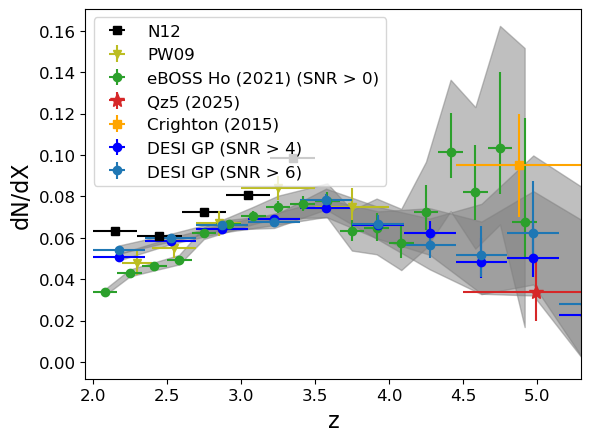

In [7]:

# Load DLA data Noterdaeme 2012, Prochaska 2005
dla_data.dndx_not()
dla_data.dndx_pro()

# dN/dX: Ho 2021
dndx_all = np.loadtxt(os.path.join("../CDDF_analysis/dla_data/ho21/", "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68 = np.full((N, 2), fill_value=np.nan)
dndx95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    dNdX,
    dndx68[:, 0],
    dndx68[:, 1],
    dndx95[:, 0],
    dndx95[:, 1],
) = dndx_all

plot_line_density(z_cent, dNdX, dndx68, dndx95, zmax=5, color="C2", label="eBOSS Ho (2021) (SNR > 0)")

# QZ5
xerr= np.array([np.abs(4.5 - 4.99), np.abs(5.57-4.99)])[:, None]
yerr=np.array([np.abs(0.02 - 0.034), np.abs(0.05 - 0.034)])[:, None]
plt.errorbar(np.array([4.99]), np.array([0.034]), yerr=yerr, xerr=xerr, fmt="*", color="C3", label="Qz5 (2025)", markersize=10)

# Crighton et al. (2015)
xerr= np.array([np.abs(4.45 - 4.88), np.abs(5.31-4.88)])[:, None]
yerr=np.array([np.abs(0.12 - 0.095), np.abs(0.07 - 0.095)])[:, None]
plt.errorbar(np.array([4.88]), np.array([0.095]), yerr=yerr, xerr=xerr, fmt="s", color="orange", label="Crighton (2015)")

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68 = np.full((N, 2), fill_value=np.nan)
dndx95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    dNdX,
    dndx68[:, 0],
    dndx68[:, 1],
    dndx95[:, 0],
    dndx95[:, 1],
) = dndx_all

plot_line_density(z_cent, dNdX, dndx68, dndx95, color="blue", label="DESI GP (SNR > 4)", bins_per_z=3)

# dN/dX: High SNR
dndx_all = np.loadtxt(os.path.join(high_snrsubdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68 = np.full((N, 2), fill_value=np.nan)
dndx95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    dNdX,
    dndx68[:, 0],
    dndx68[:, 1],
    dndx95[:, 0],
    dndx95[:, 1],
) = dndx_all

plot_line_density(z_cent, dNdX, dndx68, dndx95, color="C0", label="DESI GP (SNR > 6)", bins_per_z=3)

plt.xlim(1.95, 5.3)
plt.legend()

save_figure(os.path.join(outfile, "dndx"))

OmegaDLA

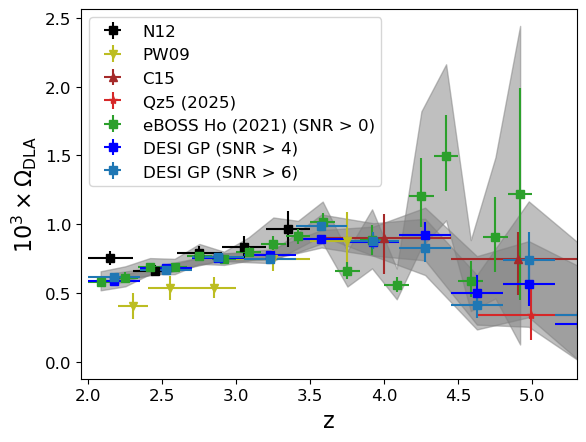

In [8]:

dla_data.omegahi_not()
dla_data.omegahi_pro()
dla_data.crighton_omega()
# dla_data.xq100_omega()

# QZ5
#He divides these measurements by 0.76,
#which he thinks gives him the neutral gas mass in DLAs, because all this hydrogen
#is neutral. However, some of the hydrogen is molecular, so the factor is daft.
#This is rho_crit at z=0
rho_crit = 9.3125685124148235e-30
#This converts from 1e8 M_sun/Mpc^3 to g/cm^3
conv = 6.7699111782945424e-33
#A factor of 0.76 from HI mass to gas mass
#Note: this factor is 0.74, so that the Noterdaeme
#Omega_DLA is numerically similar to the rho_HI of Prochaska
rhohi = np.array([0.56]) # in units of 1e-8 Msun/Mpc^3
factor = conv/rho_crit*1000
omega_DLA = rhohi*factor / 1.2 # HI to DLA conversion factor

xerr= np.array([np.abs(4.5 - 4.99), np.abs(5.57-4.99)])[:, None] *factor
yerr=np.array([np.abs(0.31 - 0.56), np.abs(0.82 - 0.56)])[:, None]*factor
plt.errorbar(np.array([4.99]), omega_DLA, yerr=yerr, xerr=xerr, fmt="*", color="C3", label="Qz5 (2025)")

# # Crighton et al. (2015)
# xerr= np.array([[np.abs(3.56 - 4.01), np.abs(4.45-4.01)],
#                 [np.abs(4.45 - 4.88), np.abs(5.31-4.88)]]) *factor
# yerr=np.array([[np.abs(1.36 - 1.73), np.abs(2.11 - 1.73)],
#                [np.abs(1.19 - 1.44), np.abs(1.73 - 1.44)]]) *factor
# plt.errorbar(np.array([4.01, 4.88]), np.array([1.73, 1.44]) *factor, yerr=yerr, xerr=xerr, fmt="x", color="orange", label="Crighton (2015)")

# OmegaDLA: Ho2021
omega_dla_all = np.loadtxt(os.path.join("../CDDF_analysis/dla_data/ho21", "omega_dla_all.txt"))
(_, N) = omega_dla_all.shape

omega_dla_68 = np.full((N, 2), fill_value=np.nan)
omega_dla_95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    omega_dla,
    omega_dla_68[:, 0],
    omega_dla_68[:, 1],
    omega_dla_95[:, 0],
    omega_dla_95[:, 1],
) = omega_dla_all

plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, zmax=5, color="C2", label="eBOSS Ho (2021) (SNR > 0)")

# OmegaDLA: Fiducial
omega_dla_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N) = omega_dla_all.shape

omega_dla_68 = np.full((N, 2), fill_value=np.nan)
omega_dla_95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    omega_dla,
    omega_dla_68[:, 0],
    omega_dla_68[:, 1],
    omega_dla_95[:, 0],
    omega_dla_95[:, 1],
) = omega_dla_all

plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, color="blue", label="DESI GP (SNR > 4)", bins_per_z=3)


# OmegaDLA : High SNR
omega_dla_all = np.loadtxt(os.path.join(high_snrsubdir, "omega_dla_all.txt"))
(_, N) = omega_dla_all.shape

omega_dla_68 = np.full((N, 2), fill_value=np.nan)
omega_dla_95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    omega_dla,
    omega_dla_68[:, 0],
    omega_dla_68[:, 1],
    omega_dla_95[:, 0],
    omega_dla_95[:, 1],
) = omega_dla_all

plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, color="C0", label="DESI GP (SNR > 6)", bins_per_z=3)

plt.xlim(1.95, 5.3)

plt.legend()

save_figure(os.path.join(outfile, "omega_dla"))